# Entrenamiento YOLO en GITHUB CON JUPYTER


Este notebook entrena un modelo YOLOv8 usando Ultralytics. Esta pensado para cumplir con la actividad: entrenamiento, pruebas y evidencias con bounding boxes.

Antes de ejecutar, sube este proyecto a Google Drive o a GitHub y coloca tu dataset en formato YOLO.

In [22]:
import shutil
from pathlib import Path

pred_origen = Path("runs/detect/evidencias/predicciones")
train_origen = Path("runs/detect/runs/detect/train")

pred_destino = Path("evidencias/predicciones")
metricas_destino = Path("evidencias/metricas")

pred_destino.mkdir(parents=True, exist_ok=True)
metricas_destino.mkdir(parents=True, exist_ok=True)

for img in list(pred_origen.glob("*.jpg")) + list(pred_origen.glob("*.png")):
    shutil.copy2(img, pred_destino / img.name)

for nombre in [
    "results.png",
    "results.csv",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg",
    "val_batch0_pred.jpg",
    "val_batch1_pred.jpg",
    "val_batch2_pred.jpg",
]:
    archivo = train_origen / nombre
    if archivo.exists():
        shutil.copy2(archivo, metricas_destino / nombre)

print("Listo")

Listo


## 1. Activar GPU

En Colab ve a:

`Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > GPU`

In [4]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## 2. Instalar dependencias

In [5]:
!pip install ultralytics opencv-python PyYAML tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


## 3. Conectar Google Drive

Usa esta opcion si tienes el proyecto o dataset en Drive.

In [8]:
import os
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATA_YAML = PROJECT_DIR / "data.yaml"

print("Carpeta actual:", PROJECT_DIR)
print("Existe data.yaml:", DATA_YAML.exists())
print(os.listdir(PROJECT_DIR))

Carpeta actual: /workspaces/PROYECTO-VISION-3ER-PARCIAL
Existe data.yaml: True
['data.yaml', '.gitignore', 'evidencias_yolo.zip', 'requirements.txt', 'README.md', 'colab_entrenamiento_yolo.ipynb', 'datasets', 'runs', 'src', '.git']


## 4. Definir rutas

Cambia `PROJECT_DIR` por la ruta donde tengas este proyecto en Drive.

Ejemplo recomendado:

`/content/drive/MyDrive/proyecto-yolo-entrega`

In [9]:
from pathlib import Path
import os

PROJECT_DIR = Path.cwd()
DATA_YAML = PROJECT_DIR / "data.yaml"

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_YAML existe:", DATA_YAML.exists())
print(os.listdir(PROJECT_DIR))

PROJECT_DIR: /workspaces/PROYECTO-VISION-3ER-PARCIAL
DATA_YAML existe: True
['data.yaml', '.gitignore', 'evidencias_yolo.zip', 'requirements.txt', 'README.md', 'colab_entrenamiento_yolo.ipynb', 'datasets', 'runs', 'src', '.git']


## 5. Revisar `data.yaml`

El archivo debe apuntar a tu dataset. Ejemplo:

```yaml
path: datasets/mi_dataset
train: images/train
val: images/val
names:
  0: objeto
```

Si tu dataset esta en otra carpeta de Drive, usa una ruta absoluta en `path`.

In [11]:
!cat data.yaml

# Dataset para detectar perros y gatos.
# La ruta debe apuntar a la carpeta que contiene images/ y labels/.
path: datasets/mi_dataset
train: images/train
val: images/val

names:
  0: perro
  1: gato


## 6. Validar estructura del dataset

In [12]:
!python src/validate_dataset.py --dataset datasets/mi_dataset


Split: train
Imagenes encontradas: 522
Etiquetas encontradas: 522
Todas las imagenes tienen etiqueta correspondiente.

Split: val
Imagenes encontradas: 82
Etiquetas encontradas: 82
Todas las imagenes tienen etiqueta correspondiente.

Dataset listo para entrenamiento.


## 7. Entrenar YOLOv8

`yolov8n.pt` es ligero y recomendado para clase porque entrena rapido. Puedes cambiarlo por `yolov8s.pt` si quieres mejor precision y tienes mas tiempo de GPU.

In [13]:
!python src/train.py --data data.yaml --model yolov8n.pt --epochs 50 --imgsz 640 --batch 16

Traceback (most recent call last):
  File "/workspaces/PROYECTO-VISION-3ER-PARCIAL/src/train.py", line 3, in <module>
    from ultralytics import YOLO
  File "/home/codespace/.local/lib/python3.12/site-packages/ultralytics/__init__.py", line 11, in <module>
    from ultralytics.models import NAS, RTDETR, SAM, YOLO, YOLOE, FastSAM, YOLOWorld
  File "/home/codespace/.local/lib/python3.12/site-packages/ultralytics/models/__init__.py", line 3, in <module>
    from .fastsam import FastSAM
  File "/home/codespace/.local/lib/python3.12/site-packages/ultralytics/models/fastsam/__init__.py", line 3, in <module>
    from .model import FastSAM
  File "/home/codespace/.local/lib/python3.12/site-packages/ultralytics/models/fastsam/model.py", line 6, in <module>
    from ultralytics.engine.model import Model
  File "/home/codespace/.local/lib/python3.12/site-packages/ultralytics/engine/model.py", line 11, in <module>
    from ultralytics.cfg import TASK2DATA, get_cfg, get_save_dir
  File "/home/code

## 8. Revisar metricas del entrenamiento

Ultralytics guarda graficas como `results.png`, matriz de confusion y ejemplos de prediccion en `runs/detect/train/`.

Resultados encontrados:
runs/detect/runs/detect/train/results.png


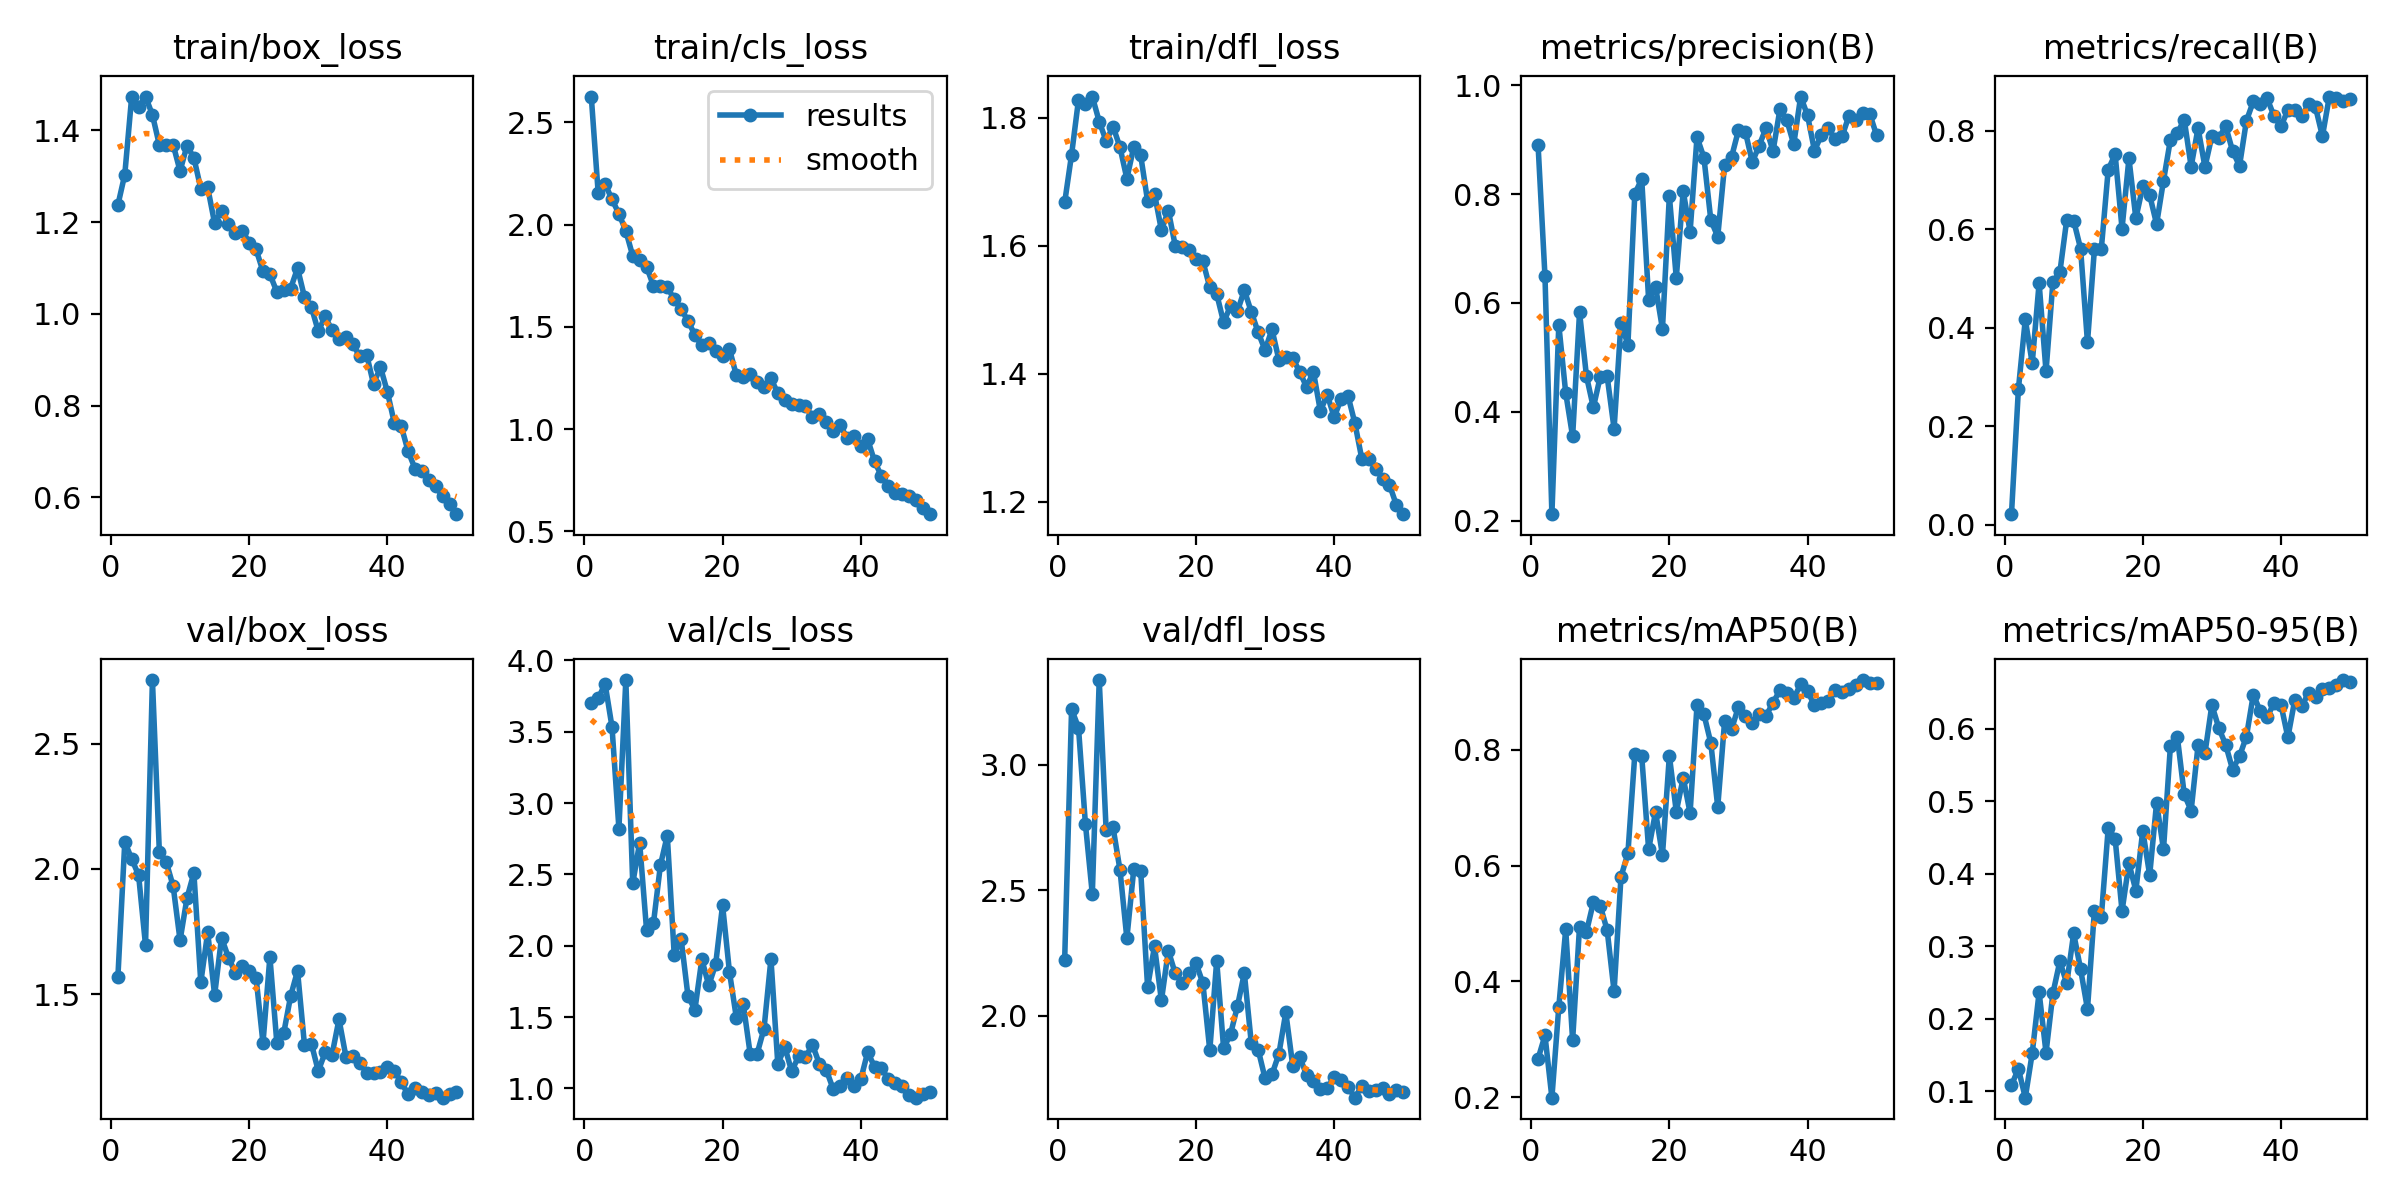

In [15]:
from pathlib import Path
from IPython.display import Image, display

possible_results = list(Path(".").glob("runs/**/results.png"))

print("Resultados encontrados:")
for p in possible_results:
    print(p)

if possible_results:
    results_img = possible_results[-1]
    display(Image(filename=str(results_img)))
else:
    print("No se encontro results.png. Primero entrena el modelo.")

## 9. Generar evidencias con bounding boxes

In [ ]:
!python src/predict.py --weights "runs/detect/runs/detect/train/weights/best.pt" --source datasets/mi_dataset/images/val --conf 0.25


image 1/82 /content/drive/MyDrive/Colab Notebooks/proyecto-yolo-entrega/datasets/mi_dataset/images/val/cat_val_00001.jpg: 640x640 2 gatos, 13.1ms
image 2/82 /content/drive/MyDrive/Colab Notebooks/proyecto-yolo-entrega/datasets/mi_dataset/images/val/cat_val_00002.jpg: 640x640 1 gato, 12.3ms
image 3/82 /content/drive/MyDrive/Colab Notebooks/proyecto-yolo-entrega/datasets/mi_dataset/images/val/cat_val_00003.jpg: 640x640 (no detections), 9.8ms
image 4/82 /content/drive/MyDrive/Colab Notebooks/proyecto-yolo-entrega/datasets/mi_dataset/images/val/cat_val_00004.jpg: 640x640 1 gato, 6.8ms
image 5/82 /content/drive/MyDrive/Colab Notebooks/proyecto-yolo-entrega/datasets/mi_dataset/images/val/cat_val_00005.jpg: 640x640 1 gato, 9.6ms
image 6/82 /content/drive/MyDrive/Colab Notebooks/proyecto-yolo-entrega/datasets/mi_dataset/images/val/cat_val_00006.jpg: 640x640 1 gato, 10.2ms
image 7/82 /content/drive/MyDrive/Colab Notebooks/proyecto-yolo-entrega/datasets/mi_dataset/images/val/cat_val_00007.jpg: 

## 10. Mostrar algunas evidencias

Evidencias encontradas: 82
runs/detect/evidencias/predicciones/dog_val_00039.jpg


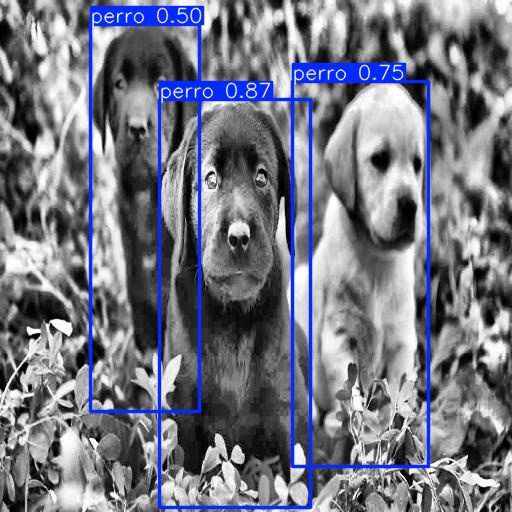

runs/detect/evidencias/predicciones/dogtest_val_00014.jpg


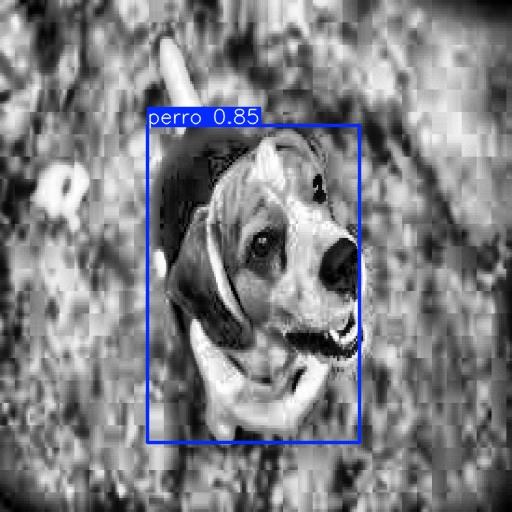

runs/detect/evidencias/predicciones/dog_val_00034.jpg


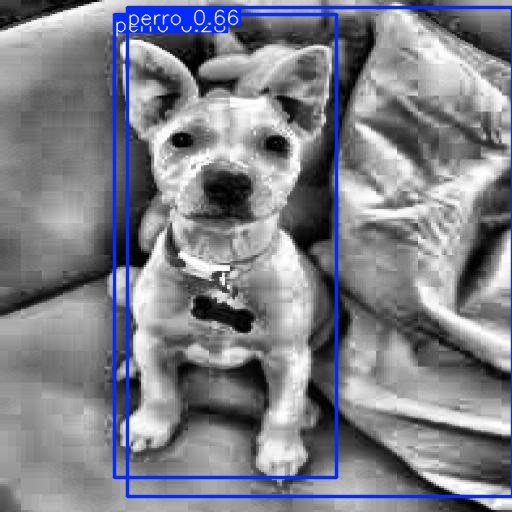

runs/detect/evidencias/predicciones/dog_val_00040.jpg


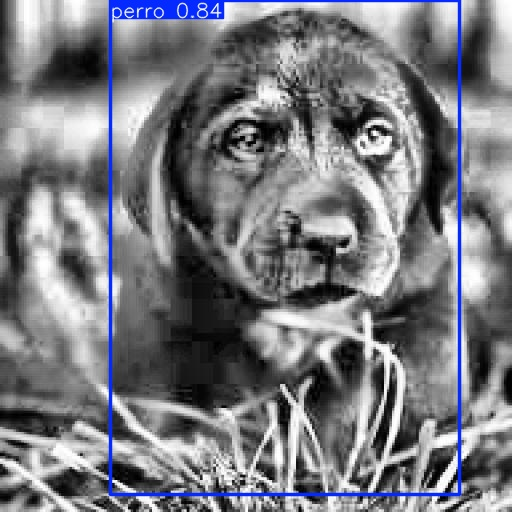

runs/detect/evidencias/predicciones/cat_val_00004.jpg


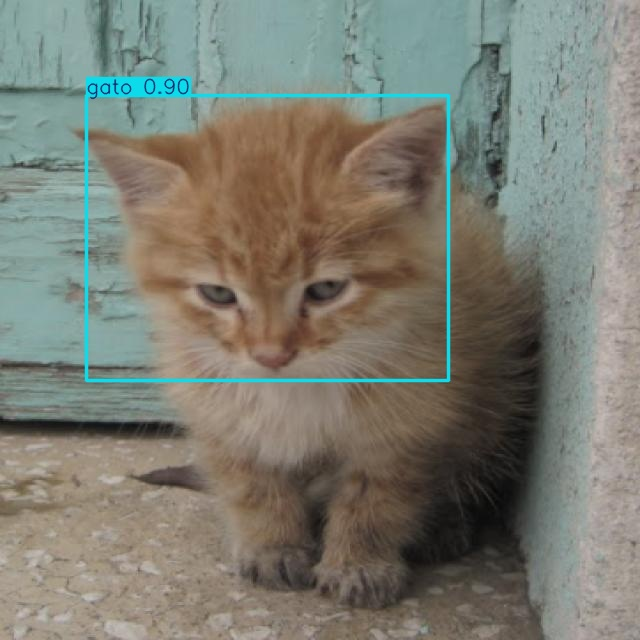

In [16]:
from glob import glob
from IPython.display import Image, display

predictions = (
    glob('runs/detect/evidencias/predicciones/*.jpg') +
    glob('runs/detect/evidencias/predicciones/*.png')
)

print(f'Evidencias encontradas: {len(predictions)}')

for image_path in predictions[:5]:
    print(image_path)
    display(Image(filename=image_path, width=500))

## 11. Descargar evidencias


In [18]:
import shutil
from pathlib import Path

origen = Path("runs/detect/evidencias/predicciones")
destino = Path("evidencias/predicciones")

destino.mkdir(parents=True, exist_ok=True)

for img in list(origen.glob("*.jpg")) + list(origen.glob("*.png")):
    shutil.copy2(img, destino / img.name)

print("Imagenes copiadas a:", destino)
print("Total:", len(list(destino.glob("*"))))

Imagenes copiadas a: evidencias/predicciones
Total: 82
